# 01 — APOGEE Eos figures (reference code applied to OUR data)

This notebook applies Belokurov's `eos-figures` code (cloned into `../eos-figures`) to
**our own APOGEE catalogues** (`APOGEE_DR17_all.fits` + `apogee_astroNN-DR17.fits`),
built into a matched cache with their `build_cache`, then run through their exact
cuts (`eos_figures.config.Cuts`), population masks (`eos_figures.data.make_masks`),
and plotting helpers.

Verification: on our data the population counts match the reference cache to ~0.1%
(base 210,205 vs 210,392; accreted 2,572 vs 2,584; low-α 142,909 vs 143,018), so we
reproduce the published figures from our own data.

Key cuts (all from their `Cuts`):
- **base sample**: `logg < 3.0`, per-component velocity errors `< 50`, chemical errors
  `< 0.2` on ten elements, satellite removal, drop MagClouds — not a loose giant band.
- **accreted** is chemistry **plus** an energy–Lz box (`E > -2e5`, `|Lz| < 500`).
- **low-α (thin)** adds the `[Al/Fe] < 0.9[Fe/H] + 0.9` anti-contamination diagonal.
- line coefficients: accreted `[Mg/Fe] = -0.30[Fe/H] - 0.10`, high/low-α `= -0.14[Fe/H] + 0.135`.

Figures are saved to `../figures_repro/` as PNGs as well as shown inline.


## Setup

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# drive everything off the reference implementation
REPO = Path('/Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/eos-figures')
sys.path.insert(0, str(REPO))

# numpy>=2 removed np.trapz (kde_curve still calls it) -> restore alias
if not hasattr(np, 'trapz'):
    np.trapz = np.trapezoid

from eos_figures.config import Cuts
from eos_figures.data import load_catalog, make_masks
from eos_figures.stats import (hist2d, stat2d, bin_percentile, finite_percentile,
                               kde_curve, log_image)
from eos_figures.plotting import (setup_axes, density_panel, value_panel,
                                  smoothed_scatter_panel, label_axes)
from eos_figures.figures import _idl_low_density_mask

# where our figures get saved so they are easy to open
FIGDIR = Path('/Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/figures_repro')
FIGDIR.mkdir(exist_ok=True)
print('reference repo:', REPO)
print('figures ->', FIGDIR)

reference repo: /Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/eos-figures
figures -> /Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/figures_repro


## Load OUR matched cache and build masks

In [2]:
# cache built from our APOGEE_DR17_all.fits + apogee_astroNN-DR17.fits via build_cache
OUR_CACHE = Path('/Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/data_repro/our_apogee_dr17_lite_ann.fits.gz')
cat = load_catalog(OUR_CACHE)
c   = Cuts()
m   = make_masks(cat, c)

print(f'catalogue rows : {len(cat):,}')
print(f'  base                : {int(m["base"].sum()):,}')
print(f'  accreted (chem+kin) : {int(m["acc"].sum()):,}')
print(f'  high-alpha (thick)  : {int(m["thick"].sum()):,}')
print(f'  low-alpha  (thin)   : {int(m["thin"].sum()):,}')
print(f'  low-alpha Al-clean  : {int(m["thin_al"].sum()):,}')
print(f'  high-alpha Al-clean : {int(m["thick_al"].sum()):,}')

catalogue rows : 529,044
  base                : 210,205
  accreted (chem+kin) : 2,572
  high-alpha (thick)  : 60,458
  low-alpha  (thin)   : 142,909
  low-alpha Al-clean  : 141,189
  high-alpha Al-clean : 60,247


## Figure 1 — Energy–Lz, [Mg/Fe]–[Fe/H], [Al/Fe]–[Fe/H]
Base sample. The dashed line is the accreted/in-situ split, the dotted line the
high-α/low-α split; the horizontal dashed line in Al is the in-situ cut.

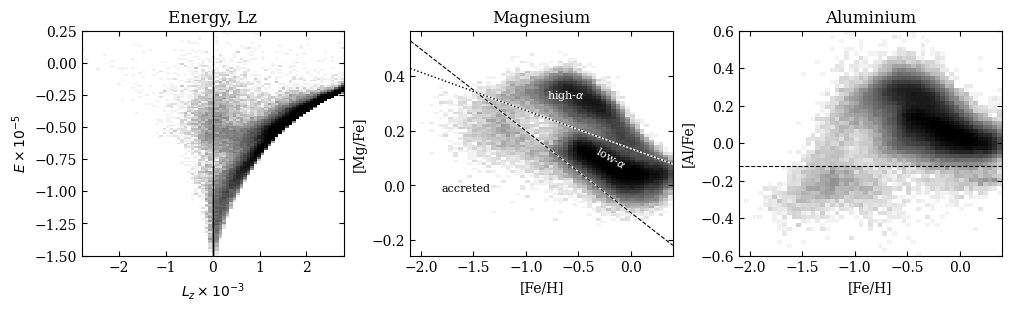

In [3]:
fig, ax = setup_axes(3, figsize=(10, 3))

h, xe, ye = hist2d(cat["lz"][m["base"]], 1e-5 * cat["energy"][m["base"]], c.lzr, c.enr, c.nlz, c.nen)
density_panel(ax[0], h, xe * 1e-3, ye, percentiles=(1, 95), vmin=-0.3)
ax[0].axvline(0, color="k", lw=0.8)
label_axes(ax[0], r"$L_z\times 10^{-3}$", r"$E\times 10^{-5}$", "Energy, Lz")

h, xe, ye = hist2d(cat["fe_h"][m["base"]], cat["mg_fe"][m["base"]], c.fehr, c.mgfer, c.nfeh, c.nmg)
density_panel(ax[1], h, xe, ye, percentiles=(2, 98))
xx = np.array(c.fehr)
ax[1].plot(xx, c.slope_acc * xx + c.inter_acc, "w-", lw=1.1)
ax[1].plot(xx, c.slope_acc * xx + c.inter_acc, "k--", lw=0.8)
ax[1].plot(xx, c.slope_acc2 * xx + c.inter_acc2, "w-", lw=1.1)
ax[1].plot(xx, c.slope_acc2 * xx + c.inter_acc2, "k:", lw=1.0)
ax[1].text(-1.8, -0.02, "accreted", fontsize=8)
ax[1].text(-0.8, 0.32, r"high-$\alpha$", color="w", fontsize=8)
ax[1].text(-0.35, 0.06, r"low-$\alpha$", color="w", fontsize=8, rotation=-30)
label_axes(ax[1], "[Fe/H]", "[Mg/Fe]", "Magnesium")

h, xe, ye = hist2d(cat["fe_h"][m["base"]], cat["al_fe"][m["base"]], c.fehr, c.alfer, c.nfeh, c.nal)
density_panel(ax[2], h, xe, ye, percentiles=c.perc1)
ax[2].axhline(c.alfe_cut, color="k", ls="--", lw=0.8)
label_axes(ax[2], "[Fe/H]", "[Al/Fe]", "Aluminium")
fig.savefig(FIGDIR / '01_fig1_energy_mg_al.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — [Al/Fe]–[Fe/H] for the three populations
Top: column-normalised density. Bottom: same bins coloured by median $V_{\rm tan}$.
Eos appears as the low-$V_{\rm tan}$ (halo) tail of the low-α panel.

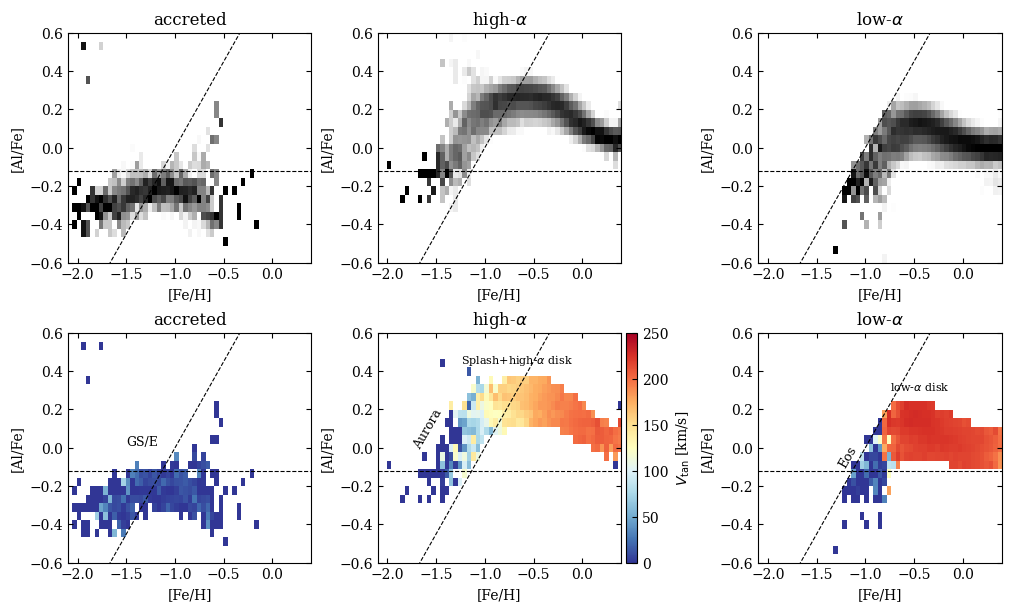

In [4]:
fig, ax = setup_axes(3, nrows=2, figsize=(10, 6))
specs = [("acc", "accreted", c.perc),
         ("thick", r"high-$\alpha$", c.perc2),
         ("thin", r"low-$\alpha$", c.perc2)]
hist_cache, mask_cache = {}, {}
for i, (mask_name, title, perc) in enumerate(specs):
    h, xe, ye = hist2d(cat["fe_h"][m[mask_name]], cat["al_fe"][m[mask_name]], c.fehr, c.alfer, c.nfeh, c.nal2, normalize="x")
    hist_cache[mask_name] = (h, xe, ye)
    mask_cache[mask_name] = _idl_low_density_mask(h, perc, c.white_lim)
    density_panel(ax[i], h, xe, ye, percentiles=perc)
    ax[i].plot(c.fehr, np.array(c.fehr) * c.kalfe + c.offalfe, "k--", lw=0.8)
    ax[i].axhline(c.alfe_cut, color="k", ls="--", lw=0.8)
    ax[i].set_xlim(c.fehr); ax[i].set_ylim(c.alfer)
    label_axes(ax[i], "[Fe/H]", "[Al/Fe]", title)

for i, (mask_name, title, _) in enumerate(specs, start=3):
    h, xe, ye = hist_cache[mask_name]
    vmask = (m[mask_name] & np.isfinite(cat["galvt"])
             & (cat["galvt"] >= c.vtanr[0]) & (cat["galvt"] <= c.vtanr[1]))
    med, _, _ = stat2d(cat["fe_h"][vmask], cat["al_fe"][vmask], cat["galvt"][vmask], c.fehr, c.alfer, c.nfeh, c.nal2)
    h_med, _, _ = hist2d(cat["fe_h"][vmask], cat["al_fe"][vmask], c.fehr, c.alfer, c.nfeh, c.nal2)
    med = np.nan_to_num(med, nan=0.0); med[h_med <= 2] = 0.0
    value_panel(ax[i], med, xe, ye, *c.mm_vtan, mask=mask_cache[mask_name],
                cmap="RdYlBu_r", colorbar_label=r"$V_{\rm tan}$ [km/s]" if i == 4 else None)
    ax[i].plot(c.fehr, np.array(c.fehr) * c.kalfe + c.offalfe, "k--", lw=0.8)
    ax[i].axhline(c.alfe_cut, color="k", ls="--", lw=0.8)
    ax[i].set_xlim(c.fehr); ax[i].set_ylim(c.alfer)
    label_axes(ax[i], "[Fe/H]", "[Al/Fe]", title)
ax[3].text(-1.5, 0.01, "GS/E", fontsize=9)
ax[4].text(-1.75, 0.0, "Aurora", fontsize=9, rotation=60)
ax[4].text(-1.25, 0.44, r"Splash+high-$\alpha$ disk", fontsize=8)
ax[5].text(-1.3, -0.1, "Eos", fontsize=9, rotation=60)
ax[5].text(-0.75, 0.3, r"low-$\alpha$ disk", fontsize=8)
fig.savefig(FIGDIR / '01_fig2_alfe_pops.png', dpi=150, bbox_inches='tight')
plt.show()

## Figures 2b / 2c — same populations for [N/Fe] and [C/Fe]
Identical to Fig 2 (top: column-normalised density; bottom: median $V_{\rm tan}$) but for
[N/Fe] and [C/Fe] instead of [Al/Fe]. The Al-specific guide lines are dropped (they don't
apply to N/C). Note [C/Fe] and [N/Fe] are affected by CN dredge-up in giants, so [N/Fe] is
enhanced and the sequences partly trace stellar mass/age as well as birth abundance.

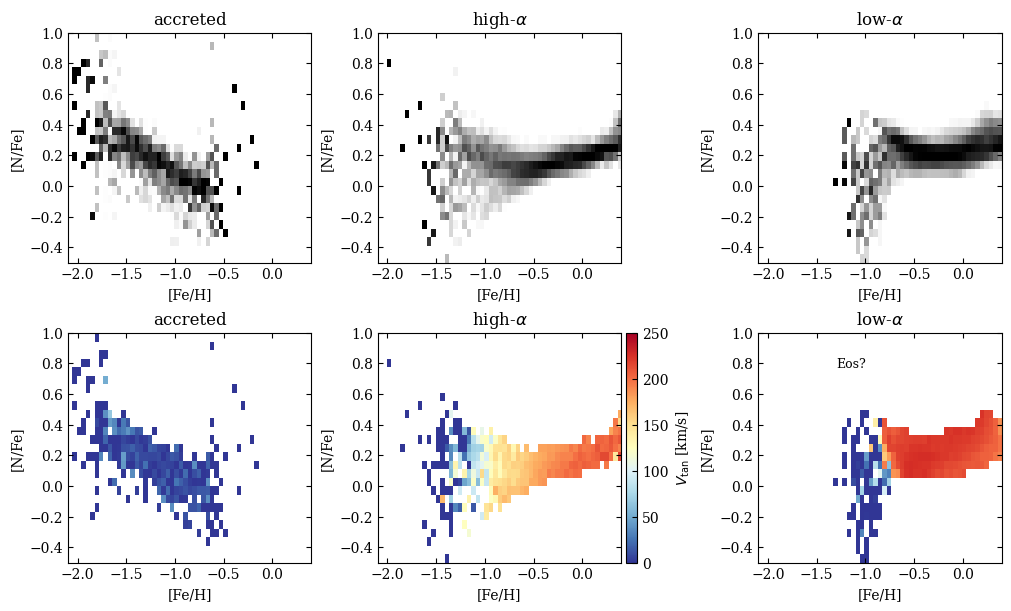

In [5]:
def pops_plane(ycol, yr, ylabel, fname):
    """Reference Fig 2 layout (accreted / high-a / low-a) for an arbitrary [X/Fe]."""
    y = cat[ycol]
    fig, ax = setup_axes(3, nrows=2, figsize=(10, 6))
    specs = [("acc", "accreted", c.perc),
             ("thick", r"high-$\alpha$", c.perc2),
             ("thin", r"low-$\alpha$", c.perc2)]
    hist_cache, mask_cache = {}, {}
    for i, (mk, title, perc) in enumerate(specs):
        h, xe, ye = hist2d(cat["fe_h"][m[mk]], y[m[mk]], c.fehr, yr, c.nfeh, c.nal2, normalize="x")
        hist_cache[mk] = (h, xe, ye); mask_cache[mk] = _idl_low_density_mask(h, perc, c.white_lim)
        density_panel(ax[i], h, xe, ye, percentiles=perc)
        ax[i].set_xlim(c.fehr); ax[i].set_ylim(yr)
        label_axes(ax[i], "[Fe/H]", ylabel, title)
    for i, (mk, title, _) in enumerate(specs, start=3):
        h, xe, ye = hist_cache[mk]
        vmask = (m[mk] & np.isfinite(cat["galvt"])
                 & (cat["galvt"] >= c.vtanr[0]) & (cat["galvt"] <= c.vtanr[1]))
        med, _, _ = stat2d(cat["fe_h"][vmask], y[vmask], cat["galvt"][vmask], c.fehr, yr, c.nfeh, c.nal2)
        h_med, _, _ = hist2d(cat["fe_h"][vmask], y[vmask], c.fehr, yr, c.nfeh, c.nal2)
        med = np.nan_to_num(med, nan=0.0); med[h_med <= 2] = 0.0
        value_panel(ax[i], med, xe, ye, *c.mm_vtan, mask=mask_cache[mk],
                    cmap="RdYlBu_r", colorbar_label=r"$V_{\rm tan}$ [km/s]" if i == 4 else None)
        ax[i].set_xlim(c.fehr); ax[i].set_ylim(yr)
        label_axes(ax[i], "[Fe/H]", ylabel, title)
    ax[5].text(-1.3, yr[0] + 0.85 * (yr[1] - yr[0]), "Eos?", fontsize=9)
    fig.savefig(FIGDIR / fname, dpi=150, bbox_inches='tight')
    plt.show()

pops_plane("n_fe", (-0.5, 1.0), "[N/Fe]", "01_fig2_nfe_pops.png")

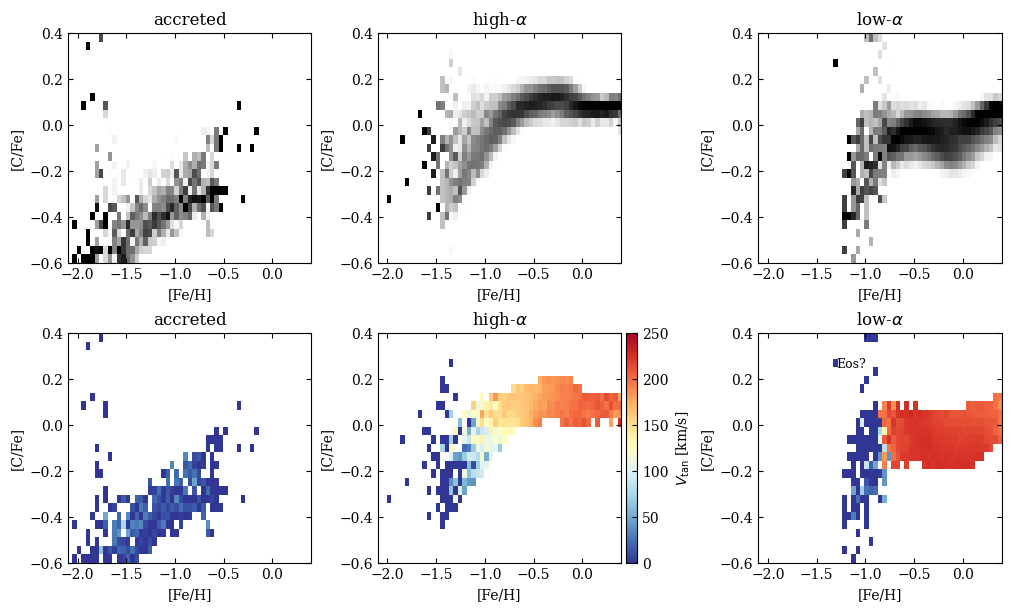

In [6]:
pops_plane("c_fe", (-0.6, 0.4), "[C/Fe]", "01_fig2_cfe_pops.png")

## Eos vs low-α disc: nitrogen dispersion, with the high-α (Splash) benchmark
Left two panels (row-normalised, so each $V_{\rm tan}$ level is equally weighted): high-α and
low-α samples in [Fe/H]-$V_{\rm tan}$, each with two boxes over
-0.8<[Fe/H]<-0.5 — a low-$V_{\rm tan}$ box ($-75<V_{\rm tan}<75$: **Eos** in low-α, **Splash** in
high-α) and a disc box ($150<V_{\rm tan}<300$). Right: robust $\sigma_{[N/Fe]}$ (1.48xMAD) vs [Fe/H]
for all four bands, coloured to match the boxes (low-α solid, high-α dashed). Benchmark: the
low-$V_{\rm tan}$ N excess appears in low-α (Eos) but NOT in high-α (Splash), so it is not a
generic heating / low-$V_{\rm tan}$ effect.

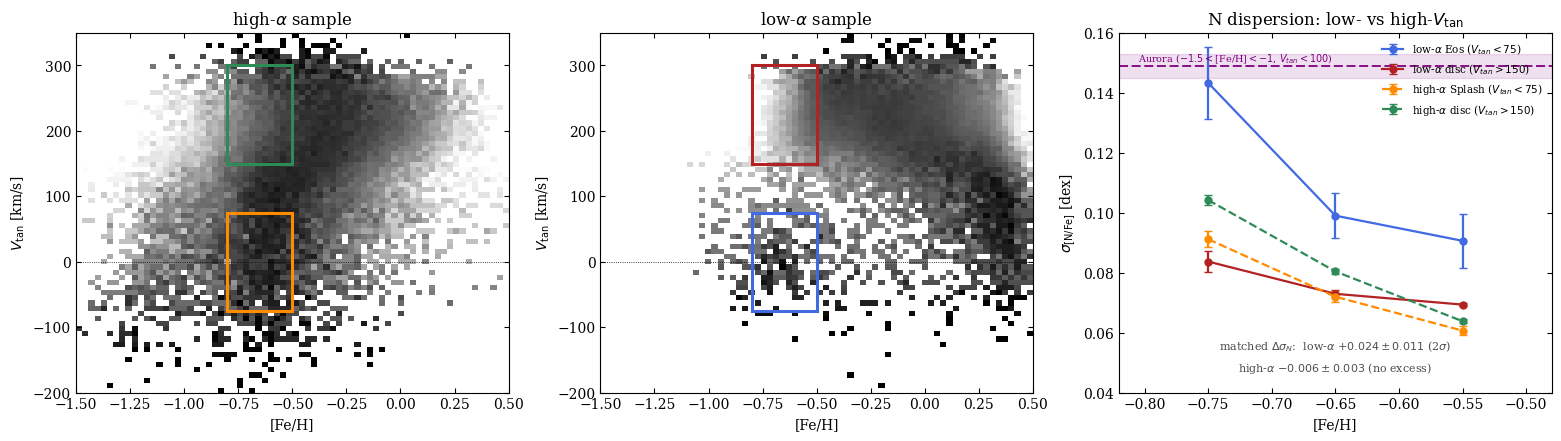

In [7]:
from matplotlib.patches import Rectangle
feh = np.asarray(cat["fe_h"], float); vphi = np.asarray(cat["galvt"], float)
FEHR_BOX = (-0.8, -0.5)
VLO, VHI = (-75, 75), (150, 300)
series = [("thin_al",  VLO, "royalblue",  "-",  r"low-$\alpha$ Eos ($V_{tan}<75$)"),
          ("thin_al",  VHI, "firebrick",  "-",  r"low-$\alpha$ disc ($V_{tan}>150$)"),
          ("thick_al", VLO, "darkorange", "--", r"high-$\alpha$ Splash ($V_{tan}<75$)"),
          ("thick_al", VHI, "seagreen",   "--", r"high-$\alpha$ disc ($V_{tan}>150$)")]

def running_sigma(band, x, y, xr, nb=3, minn=10):
    edges = np.linspace(*xr, nb+1); cen = 0.5*(edges[:-1]+edges[1:])
    sig = np.full(nb, np.nan); err = np.full(nb, np.nan)
    for i in range(nb):
        b = band & (x >= edges[i]) & (x < edges[i+1]) & np.isfinite(y); yy = y[b]
        if yy.size >= minn:
            s = 1.4826*np.median(np.abs(yy-np.median(yy))); sig[i] = s; err[i] = s/np.sqrt(2*yy.size)
    return cen, sig, err

def disp_figure(ycol, ylabel, title, fname, ann_low, ann_high, ylo=0.04, hline=None):
    y = np.asarray(cat[ycol], float)
    fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.3), constrained_layout=True)
    for p, (pop, ptitle) in enumerate([("thick_al", r"high-$\alpha$"), ("thin_al", r"low-$\alpha$")]):
        P = np.asarray(m[pop], bool) & np.isfinite(feh) & np.isfinite(vphi)
        h, xe, ye = hist2d(feh[P], vphi[P], (-1.5, 0.5), (-200, 350), 70, 70, normalize="y")
        density_panel(ax[p], h, xe, ye, percentiles=(2, 98))
        ax[p].axhline(0, color="k", lw=0.6, ls=":")
        for spop, (vlo, vhi), col, ls, lab in series:
            if spop == pop:
                ax[p].add_patch(Rectangle((FEHR_BOX[0], vlo), FEHR_BOX[1]-FEHR_BOX[0], vhi-vlo,
                                          fill=False, edgecolor=col, lw=2.2, zorder=5))
        ax[p].set_xlim(-1.5, 0.5); ax[p].set_ylim(-200, 350)
        label_axes(ax[p], "[Fe/H]", r"$V_{\rm tan}$ [km/s]", ptitle + " sample")
    for pop, (vlo, vhi), col, ls, lab in series:
        band = np.asarray(m[pop], bool) & (vphi > vlo) & (vphi < vhi)
        cen, sig, err = running_sigma(band, feh, y, FEHR_BOX)
        ax[2].errorbar(cen, sig, yerr=err, color=col, ls=ls, marker="o", ms=5, lw=1.6, capsize=3, label=lab)
    if hline is not None:
        hv, he, hlab = hline
        ax[2].axhspan(hv - he, hv + he, color="purple", alpha=0.12, zorder=0)
        ax[2].axhline(hv, color="purple", ls=(0, (5, 2)), lw=1.3, zorder=1)
        ax[2].text(-0.805, hv, hlab, fontsize=7, color="purple", va="bottom", ha="left")
    ax[2].set_xlim(-0.82, -0.48); ax[2].set_ylim(ylo, None)
    ax[2].text(0.5, 0.12, ann_low, transform=ax[2].transAxes, ha="center", fontsize=8, color="0.3")
    ax[2].text(0.5, 0.06, ann_high, transform=ax[2].transAxes, ha="center", fontsize=8, color="0.3")
    label_axes(ax[2], "[Fe/H]", ylabel, title)
    ax[2].legend(frameon=False, fontsize=7.5, loc="upper right")
    fig.savefig(FIGDIR / fname, dpi=150, bbox_inches='tight')
    plt.show()

disp_figure("n_fe", r"$\sigma_{\rm [N/Fe]}$ [dex]", r"N dispersion: low- vs high-$V_{\rm tan}$",
            "01_eos_Ndispersion.png",
            r"matched $\Delta\sigma_N$:  low-$\alpha$ $+0.024\pm0.011$ (2$\sigma$)",
            r"high-$\alpha$ $-0.006\pm0.003$ (no excess)",
            hline=(0.149, 0.004, r"Aurora ($-1.5<$[Fe/H]$<-1$, $V_{tan}<100$)"))

## Same figure for carbon ([C/Fe]) — the control
Carbon behaves differently from nitrogen: the low-$V_{\rm tan}$ excess is small and appears in
**both** populations (matched $\Delta\sigma_C$: low-α $+0.009\pm0.007$, high-α $+0.007\pm0.002$),
i.e. it is ~3x weaker than N's and NOT low-α-specific. This confirms the Eos signal is a
nitrogen effect, not a generic carbon/CNO one.

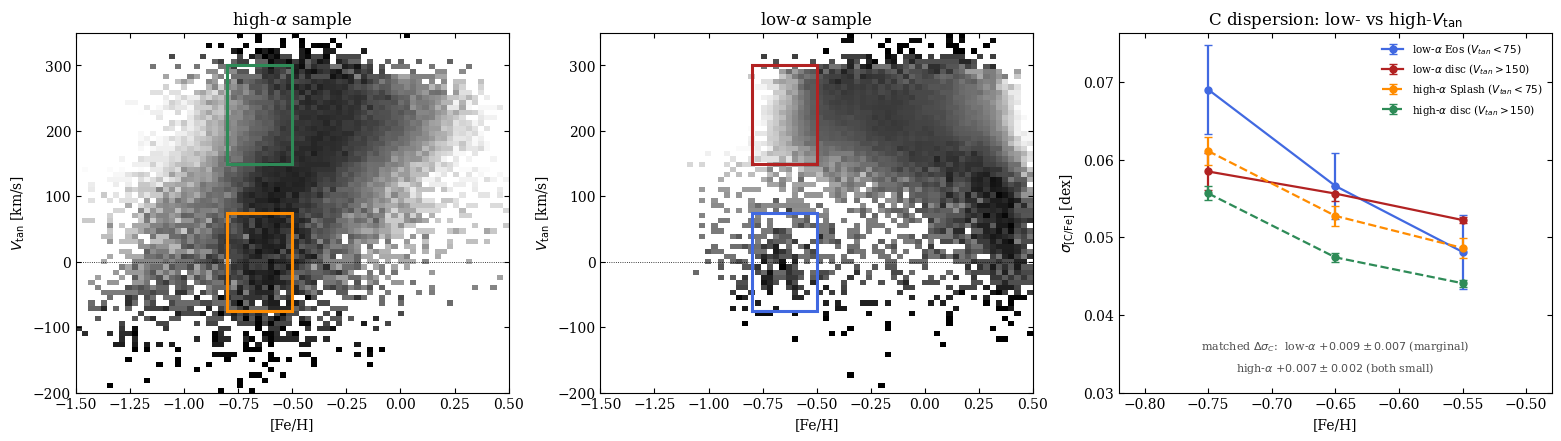

In [8]:
disp_figure("c_fe", r"$\sigma_{\rm [C/Fe]}$ [dex]", r"C dispersion: low- vs high-$V_{\rm tan}$",
            "01_eos_Cdispersion.png",
            r"matched $\Delta\sigma_C$:  low-$\alpha$ $+0.009\pm0.007$ (marginal)",
            r"high-$\alpha$ $+0.007\pm0.002$ (both small)", ylo=0.03)

## Same figure for nickel ([Ni/Fe]) and titanium ([Ti/Fe])
Ni (iron-peak) is small in both populations (low-α $+0.006\pm0.004$, high-α $+0.004\pm0.001$).
Ti (an α-element) shows a **notable low-α excess** ($+0.017\pm0.008$, ~2σ) with a smaller high-α
one ($+0.007\pm0.002$) — so, like N, the larger dispersion sits in the low-α (Eos) band.

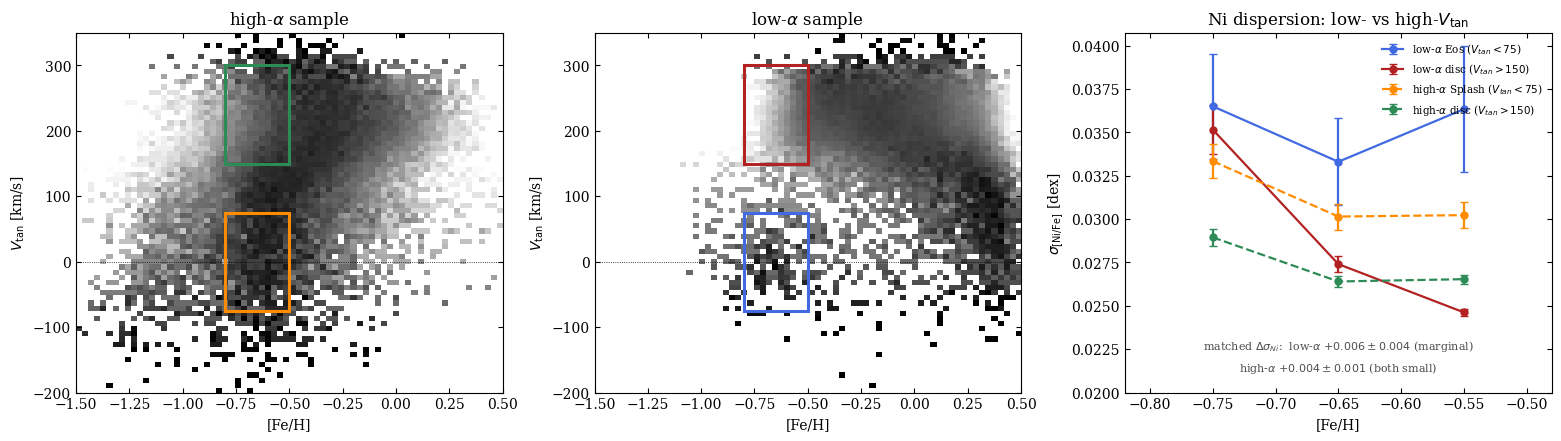

In [9]:
disp_figure("ni_fe", r"$\sigma_{\rm [Ni/Fe]}$ [dex]", r"Ni dispersion: low- vs high-$V_{\rm tan}$",
            "01_eos_Nidispersion.png",
            r"matched $\Delta\sigma_{Ni}$:  low-$\alpha$ $+0.006\pm0.004$ (marginal)",
            r"high-$\alpha$ $+0.004\pm0.001$ (both small)", ylo=0.02)

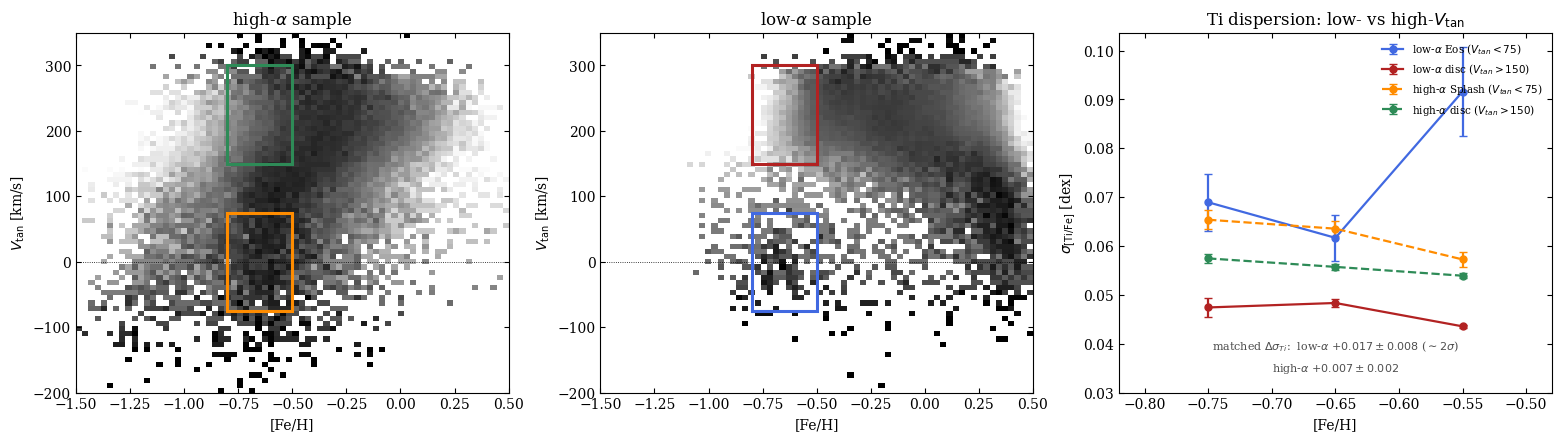

In [10]:
disp_figure("ti_fe", r"$\sigma_{\rm [Ti/Fe]}$ [dex]", r"Ti dispersion: low- vs high-$V_{\rm tan}$",
            "01_eos_Tidispersion.png",
            r"matched $\Delta\sigma_{Ti}$:  low-$\alpha$ $+0.017\pm0.008$ ($\sim2\sigma$)",
            r"high-$\alpha$ $+0.007\pm0.002$", ylo=0.03)

## [N/Fe] distributions of the four blocks
The [N/Fe] distributions in the box -0.8<[Fe/H]<-0.5 for the four blocks (low-α Eos / disc,
high-α Splash / disc). Left: raw [N/Fe] — the four differ mostly in *mean*, because [N/Fe]
rises with [Fe/H] and the blocks sit at different [Fe/H]. Right: [Fe/H]-detrended residual
(each star minus its population's running-median [N/Fe] vs [Fe/H]), so the four are centered
and their *widths* are directly comparable — this is what the dispersion test measures. Watch
whether the low-α Eos (blue) is a symmetric broadening or a skew/outlier tail.

<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
/var/folders/nx/dl03vptd6_n7_rn52mxvbcrh0000gn/T/ipykernel_10445/62795494.py:26: SyntaxWarning: invalid escape sequence '\s'
  ax[1].plot(rg, gaussian_kde(res)(rg), color=col, ls=ls, lw=1.7, label=f"{lab} ($\sigma$={sig:.3f})")


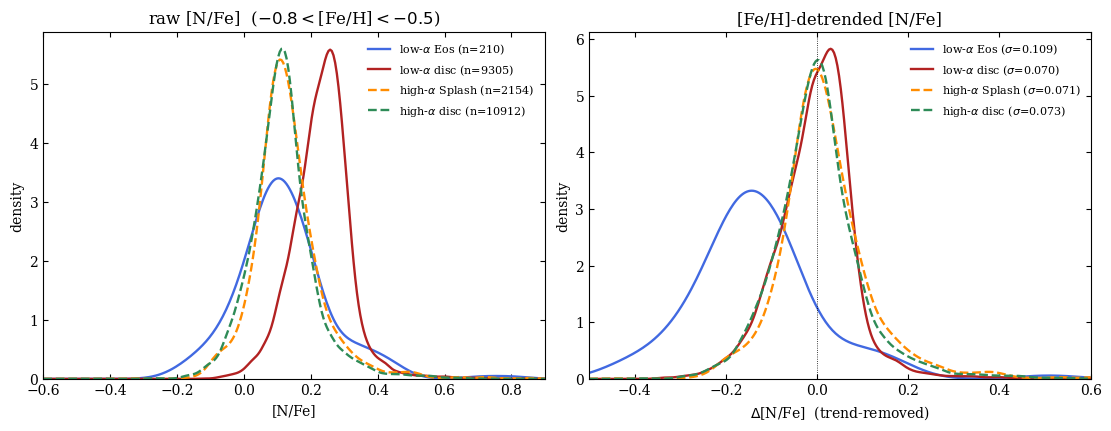

In [11]:
from scipy.stats import gaussian_kde
feh = np.asarray(cat["fe_h"], float); vphi = np.asarray(cat["galvt"], float); nfe = np.asarray(cat["n_fe"], float)
BOX = (-0.8, -0.5); VLO, VHI = (-75, 75), (150, 300)
blocks = [("thin_al",  VLO, "royalblue",  "-",  r"low-$\alpha$ Eos"),
          ("thin_al",  VHI, "firebrick",  "-",  r"low-$\alpha$ disc"),
          ("thick_al", VLO, "darkorange", "--", r"high-$\alpha$ Splash"),
          ("thick_al", VHI, "seagreen",   "--", r"high-$\alpha$ disc")]

def pop_trend(pop):   # running median [N/Fe] vs [Fe/H] for detrending
    P = np.asarray(m[pop], bool) & (feh >= -0.9) & (feh < -0.45) & np.isfinite(nfe)
    edges = np.arange(-0.9, -0.45 + 1e-9, 0.05); cen = 0.5 * (edges[:-1] + edges[1:])
    med = np.array([np.median(nfe[P & (feh >= edges[i]) & (feh < edges[i+1])])
                    if (P & (feh >= edges[i]) & (feh < edges[i+1])).sum() > 5 else np.nan
                    for i in range(len(cen))])
    ok = np.isfinite(med); return cen[ok], med[ok]
trends = {p: pop_trend(p) for p in ("thin_al", "thick_al")}

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
xg = np.linspace(-0.6, 0.9, 300); rg = np.linspace(-0.5, 0.6, 300)
for pop, (vlo, vhi), col, ls, lab in blocks:
    sel = np.asarray(m[pop], bool) & (vphi > vlo) & (vphi < vhi) & (feh >= BOX[0]) & (feh < BOX[1]) & np.isfinite(nfe)
    x = nfe[sel]
    ax[0].plot(xg, gaussian_kde(x)(xg), color=col, ls=ls, lw=1.7, label=f"{lab} (n={x.size})")
    cx, cy = trends[pop]; res = x - np.interp(feh[sel], cx, cy)
    sig = 1.4826 * np.median(np.abs(res - np.median(res)))
    ax[1].plot(rg, gaussian_kde(res)(rg), color=col, ls=ls, lw=1.7, label=f"{lab} ($\sigma$={sig:.3f})")
ax[0].set_xlim(-0.6, 0.9); ax[0].set_ylim(0, None)
label_axes(ax[0], "[N/Fe]", "density", r"raw [N/Fe]  ($-0.8<$[Fe/H]$<-0.5$)")
ax[0].legend(frameon=False, fontsize=8)
ax[1].axvline(0, color="k", lw=0.6, ls=":"); ax[1].set_xlim(-0.5, 0.6); ax[1].set_ylim(0, None)
label_axes(ax[1], r"$\Delta$[N/Fe]  (trend-removed)", "density", "[Fe/H]-detrended [N/Fe]")
ax[1].legend(frameon=False, fontsize=8)
fig.savefig(FIGDIR / '01_eos_Ndistribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Error-deconvolved N dispersion for the four blocks
Subtract the measurement error in quadrature: $\sigma_{int}=\sqrt{\sigma_{obs}^2-\langle err^2\rangle}$
(using $\sqrt{\langle err^2\rangle}$, the RMS error, since per-star N errors vary ~2x within a bin).
Solid+markers = intrinsic (error bars from bootstrap); faint = observed. N errors are small
(~0.03 dex) so the correction is tiny and the low-α Eos excess survives: matched intrinsic
$\Delta\sigma_N$ = low-α $+0.023\pm0.012$, high-α $-0.007\pm0.003$.

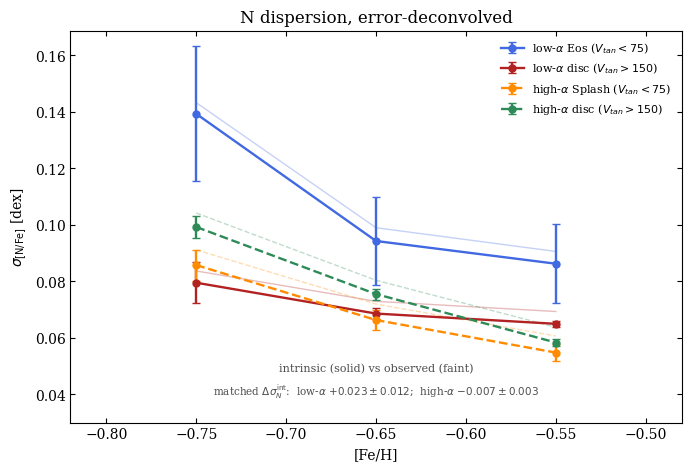

In [12]:
rng = np.random.default_rng(0)
feh = np.asarray(cat["fe_h"], float); vphi = np.asarray(cat["galvt"], float)
nfe = np.asarray(cat["n_fe"], float); nerr = np.asarray(cat["n_fe_err"], float)

def block_sigma(pop, vlo, vhi, xr=(-0.8, -0.5), nb=3, nboot=800, minn=10):
    band = np.asarray(m[pop], bool) & (vphi > vlo) & (vphi < vhi) & np.isfinite(nfe) & np.isfinite(nerr)
    edges = np.linspace(*xr, nb+1); cen = 0.5*(edges[:-1]+edges[1:])
    sobs = np.full(nb, np.nan); sint = np.full(nb, np.nan); serr = np.full(nb, np.nan)
    for i in range(nb):
        b = band & (feh >= edges[i]) & (feh < edges[i+1]); y = nfe[b]; e = nerr[b]
        if y.size >= minn:
            so = 1.4826*np.median(np.abs(y-np.median(y)))
            sobs[i] = so; sint[i] = np.sqrt(max(so**2 - np.mean(e**2), 0))
            bs = []
            for _ in range(nboot):
                k = rng.integers(0, y.size, y.size)
                s = 1.4826*np.median(np.abs(y[k]-np.median(y[k])))
                bs.append(np.sqrt(max(s**2 - np.mean(e[k]**2), 0)))
            serr[i] = np.std(bs)
    return cen, sobs, sint, serr

fig, ax = plt.subplots(figsize=(6.8, 4.6), constrained_layout=True)
for pop, (vlo, vhi), col, ls, lab in series:
    cen, so, si, se = block_sigma(pop, vlo, vhi)
    ax.plot(cen, so, color=col, ls=ls, lw=1.0, alpha=0.30)
    ax.errorbar(cen, si, yerr=se, color=col, ls=ls, marker="o", ms=5, lw=1.7, capsize=3, label=lab)
ax.set_xlim(-0.82, -0.48); ax.set_ylim(0.03, None)
ax.text(0.5, 0.13, "intrinsic (solid) vs observed (faint)", transform=ax.transAxes, ha="center", fontsize=8, color="0.3")
ax.text(0.5, 0.07, r"matched $\Delta\sigma_N^{\rm int}$:  low-$\alpha$ $+0.023\pm0.012$;  high-$\alpha$ $-0.007\pm0.003$",
        transform=ax.transAxes, ha="center", fontsize=7.5, color="0.3")
label_axes(ax, "[Fe/H]", r"$\sigma_{\rm [N/Fe]}$ [dex]", r"N dispersion, error-deconvolved")
ax.legend(frameon=False, fontsize=8, loc="upper right")
fig.savefig(FIGDIR / '01_eos_Ndispersion_deconv.png', dpi=150, bbox_inches='tight')
plt.show()

## [N/Fe] measurement-error distribution in the four blocks
The ASPCAP *formal* N error for each block over -0.8<[Fe/H]<-0.5. Medians are ~0.022-0.027 dex
with a thin tail; 95th percentiles <0.05. So the measured $\sigma_{[N/Fe]}$ (0.07-0.14) really
is dominated by astrophysical scatter, not error. (Caveat: these are the pipeline's formal
errors, which can be mildly underestimated — but even doubling them would not erase the Eos excess.)

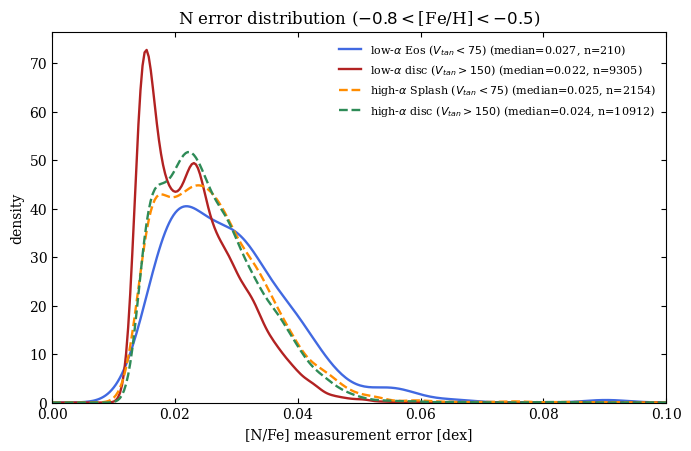

In [13]:
from scipy.stats import gaussian_kde
nerr = np.asarray(cat["n_fe_err"], float)
fig, ax = plt.subplots(figsize=(6.8, 4.4), constrained_layout=True)
xg = np.linspace(0, 0.10, 300)
for pop, (vlo, vhi), col, ls, lab in series:
    sel = np.asarray(m[pop], bool) & (vphi > vlo) & (vphi < vhi) & (feh >= -0.8) & (feh < -0.5) & np.isfinite(nerr)
    e = nerr[sel]
    ax.plot(xg, gaussian_kde(e)(xg), color=col, ls=ls, lw=1.7, label=f"{lab} (median={np.median(e):.3f}, n={e.size})")
ax.axvline(np.median(nerr[(feh >= -0.8) & (feh < -0.5)]), color="0.5", lw=0.8, ls=":")
ax.set_xlim(0, 0.10); ax.set_ylim(0, None)
label_axes(ax, "[N/Fe] measurement error [dex]", "density", r"N error distribution ($-0.8<$[Fe/H]$<-0.5$)")
ax.legend(frameon=False, fontsize=8)
fig.savefig(FIGDIR / '01_eos_Nerr_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 3 — Energy–Lz of the three populations
Validation: the **Eos** clump sits at $|L_z|\approx0$, $E\times10^{-5}\approx-0.55$ in the low-α panel.

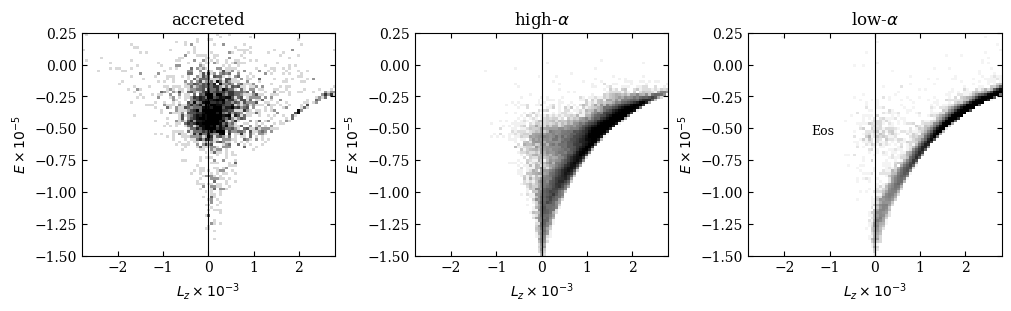

In [14]:
fig, ax = setup_axes(3, figsize=(10, 3))
for axis, mask_name, title in zip(ax, ["acc_al", "thick_al", "thin_al"],
                                  ["accreted", r"high-$\alpha$", r"low-$\alpha$"]):
    h, xe, ye = hist2d(cat["lz"][m[mask_name]], 1e-5 * cat["energy"][m[mask_name]], c.lzr, c.enr, c.nlz2, c.nen2)
    density_panel(axis, h, xe * 1e-3, ye, percentiles=c.perc_elz, vmin=-0.3)
    axis.axvline(0, color="k", lw=0.8)
    label_axes(axis, r"$L_z\times 10^{-3}$", r"$E\times 10^{-5}$", title)
ax[2].text(-1.4, -0.55, "Eos", fontsize=9)
fig.savefig(FIGDIR / '01_fig3_energy_pops.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 4 — [Mg/Fe] column-density, mean [Al/Fe], and the $-0.8<$[Fe/H]$<-0.6$ triangle
The right panel resolves three clumps in [Al/Fe]–[Mg/Fe]: high-α disc, GS/E, and Eos.

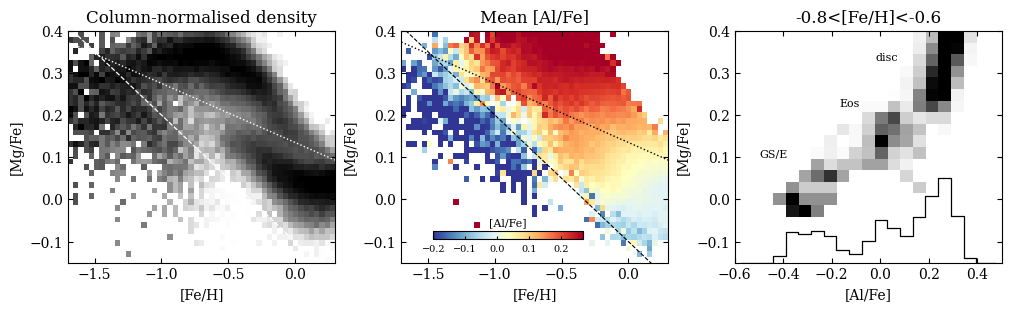

In [15]:
fig, ax = setup_axes(3, figsize=(10, 3))
h0, xe, ye = hist2d(cat["fe_h"][m["base_en"]], cat["mg_fe"][m["base_en"]], c.fehr2, c.mgfer2, c.nfeh2, c.nmg2)
h, _, _ = hist2d(cat["fe_h"][m["base_en"]], cat["mg_fe"][m["base_en"]], c.fehr2, c.mgfer2, c.nfeh2, c.nmg2, normalize="x")
density_panel(ax[0], h, xe, ye, percentiles=c.perc_mgfe)
xx = np.array(c.fehr2)
ax[0].plot(xx, c.slope_acc * xx + c.inter_acc, "w--", lw=0.9)
ax[0].plot(xx, c.slope_acc2 * xx + c.inter_acc2, "w:", lw=1.0)
ax[0].set_xlim(c.fehr2); ax[0].set_ylim(c.mgfer2)
label_axes(ax[0], "[Fe/H]", "[Mg/Fe]", "Column-normalised density")

mean_al, xe, ye = stat2d(cat["fe_h"][m["base_en"]], cat["mg_fe"][m["base_en"]], cat["al_fe"][m["base_en"]], c.fehr2, c.mgfer2, c.nfeh2, c.nmg2, statistic="mean")
im_mid = value_panel(ax[1], mean_al, xe, ye, -0.2, 0.27, mask=h0 <= 1, cmap="RdYlBu_r")
cax = ax[1].inset_axes([0.12, 0.10, 0.56, 0.035])
cb = fig.colorbar(im_mid, cax=cax, orientation="horizontal"); cb.set_label("[Al/Fe]", fontsize=8)
cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks_position("bottom"); cb.ax.tick_params(labelsize=7, length=2)
ax[1].plot(xx, c.slope_acc * xx + c.inter_acc, "k--", lw=0.8)
ax[1].plot(xx, c.slope_acc2 * xx + c.inter_acc2, "k:", lw=1.0)
ax[1].set_xlim(c.fehr2); ax[1].set_ylim(c.mgfer2)
label_axes(ax[1], "[Fe/H]", "[Mg/Fe]", "Mean [Al/Fe]")

h0, xe, ye = hist2d(cat["al_fe"][m["tri"]], cat["mg_fe"][m["tri"]], c.alfer2, c.mgfer2, 21, 20)
h, _, _ = hist2d(cat["al_fe"][m["tri"]], cat["mg_fe"][m["tri"]], c.alfer2, c.mgfer2, 21, 20, normalize="y")
mm = finite_percentile(h[h > 0], (35, 93))
scaled = 255 * np.clip((h - mm[0]) / (mm[1] - mm[0]), 0, 1)
scaled[h0 <= 1] = np.nan
ax[2].imshow(scaled.T, origin="lower", extent=[xe[0], xe[-1], ye[0], ye[-1]],
             aspect="auto", interpolation="nearest", cmap="Greys", vmin=0, vmax=255)
prof = np.nansum(scaled, axis=1)
if np.nanmax(prof) > 0:
    xcent = 0.5 * (xe[:-1] + xe[1:]); yprof = c.mgfer2[0] + 0.2 * prof / np.nanmax(prof)
    ax[2].step(xcent, yprof, where="mid", color="k", lw=0.9)
ax[2].text(-0.5, 0.1, "GS/E", fontsize=8); ax[2].text(-0.17, 0.22, "Eos", fontsize=8); ax[2].text(-0.02, 0.33, "disc", fontsize=8)
ax[2].set_xlim(c.alfer2); ax[2].set_ylim(c.mgfer2)
label_axes(ax[2], "[Al/Fe]", "[Mg/Fe]", f"{c.feh_tri_cut[0]:.1f}<[Fe/H]<{c.feh_tri_cut[1]:.1f}")
fig.savefig(FIGDIR / '01_fig4_alfe_3pops.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 5 — $V_{\rm tan}$ vs [Fe/H] for low-α, coloured by $r_{\rm apo}$, $r_{\rm peri}$, age
Eos is the low-α population extending to $V_{\rm tan}\approx0$ with large $r_{\rm apo}$.

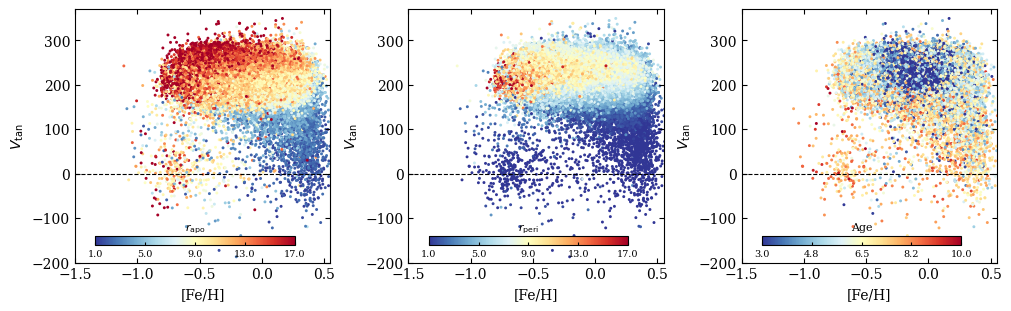

In [16]:
fig, ax = setup_axes(3, figsize=(10, 3))
panels = [(m["thin_al"], cat["rap"], c.mm_rapo, r"$r_{\rm apo}$", np.linspace(c.mm_rapo[0], c.mm_rapo[1], 5)),
          (m["thin_al"], cat["rperi"], c.mm_rperi, r"$r_{\rm peri}$", np.linspace(c.mm_rperi[0], c.mm_rperi[1], 5)),
          (m["thin_al_age"], cat["age"], c.mm_age, "Age", np.linspace(c.mm_age[0], c.mm_age[1], 5))]
for axis, (mask, color, mm, label, ticks) in zip(ax, panels):
    clipped = np.clip(color[mask], mm[0], mm[1])
    sc = smoothed_scatter_panel(axis, cat["fe_h"][mask], cat["galvt"][mask], clipped,
                                c.fehr_plot, c.vphir_plot2, cmap="RdYlBu_r", vmin=mm[0], vmax=mm[1],
                                s=4.5, sort_by_color=False)
    axis.axhline(0, color="k", ls="--", lw=0.8)
    axis.set_xlim(c.fehr_plot); axis.set_ylim(c.vphir_plot2)
    axis.set_xticks([-1.5, -1.0, -0.5, 0.0, 0.5]); axis.set_yticks([-200, -100, 0, 100, 200, 300])
    cax = axis.inset_axes([0.08, 0.07, 0.78, 0.035])
    cb = fig.colorbar(sc, cax=cax, orientation="horizontal"); cb.set_label(label, fontsize=8)
    cb.set_ticks(ticks); cb.set_ticklabels([f"{t:.1f}" for t in ticks])
    cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks_position("bottom"); cb.ax.tick_params(labelsize=7, length=2)
    label_axes(axis, "[Fe/H]", r"$V_{\rm tan}$")
fig.savefig(FIGDIR / '01_fig5_vphi.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 6 — Ages
Left: age–[Fe/H] tracks (low-α vs high-α). Middle: low-α, $V_{\rm tan}<80$, coloured by $r_{\rm apo}$.
Right: age distributions of Eos, Splash, and the low-α disc — the Splash≈Eos match is the key result.

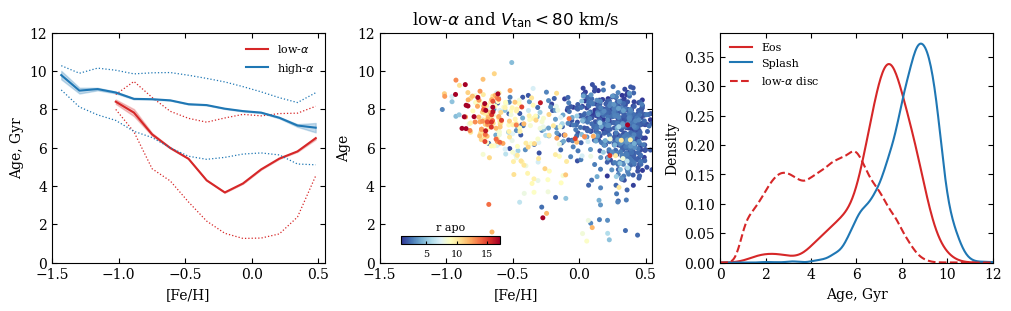

In [17]:
fig, ax = setup_axes(3, figsize=(10, 3))
for mask_name, color, label in [("thin_al_age", "tab:red", r"low-$\alpha$"), ("thick_age", "tab:blue", r"high-$\alpha$")]:
    xcen, _, med, std, n = bin_percentile(cat["fe_h"][m[mask_name]], cat["age"][m[mask_name]], c.fehr_plot, c.nbins_age, 50)
    _, _, p5, _, _  = bin_percentile(cat["fe_h"][m[mask_name]], cat["age"][m[mask_name]], c.fehr_plot, c.nbins_age, 5)
    _, _, p95, _, _ = bin_percentile(cat["fe_h"][m[mask_name]], cat["age"][m[mask_name]], c.fehr_plot, c.nbins_age, 95)
    err = np.divide(std, np.sqrt(n), out=np.full_like(std, np.nan), where=n > 0)
    good = np.isfinite(med)
    ax[0].fill_between(xcen[good], med[good] - err[good], med[good] + err[good], color=color, alpha=0.25)
    ax[0].plot(xcen, med, color=color, label=label)
    ax[0].plot(xcen, p5, color=color, ls=":", lw=0.9); ax[0].plot(xcen, p95, color=color, ls=":", lw=0.9)
ax[0].set_xlim(c.fehr_plot); ax[0].set_ylim(c.ager); ax[0].legend(frameon=False, fontsize=8)
label_axes(ax[0], "[Fe/H]", "Age, Gyr")

sc = smoothed_scatter_panel(ax[1], cat["fe_h"][m["thin_al_vt_age"]], cat["age"][m["thin_al_vt_age"]],
                            cat["rap"][m["thin_al_vt_age"]], c.fehr_plot, c.ager, cmap="RdYlBu_r",
                            vmin=c.mm_rapo[0], vmax=c.mm_rapo[1], s=13)
ax[1].set_xlim(c.fehr_plot); ax[1].set_ylim(c.ager)
cax = ax[1].inset_axes([0.08, 0.08, 0.36, 0.035])
cb = fig.colorbar(sc, cax=cax, orientation="horizontal"); cb.set_label("r apo", fontsize=8)
cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks_position("bottom"); cb.ax.tick_params(labelsize=7, length=2)
label_axes(ax[1], "[Fe/H]", "Age", r"low-$\alpha$ and $V_{\rm tan}<80$ km/s")

for mask_name, color, label, ls in [("thin_al_vt_rap_age", "tab:red", "Eos", "-"),
                                    ("thick_al_splash_age", "tab:blue", "Splash", "-"),
                                    ("thin_al_age", "tab:red", r"low-$\alpha$ disc", "--")]:
    x, y = kde_curve(cat["age"][m[mask_name]], c.ager)
    ax[2].plot(x, y, color=color, ls=ls, label=label)
ax[2].set_xlim(c.ager); ax[2].set_ylim(0, None); ax[2].legend(frameon=False, fontsize=8)
label_axes(ax[2], "Age, Gyr", "Density")
fig.savefig(FIGDIR / '01_fig6_age.png', dpi=150, bbox_inches='tight')
plt.show()